# 0. Select latest run folder


In [1]:
from pathlib import Path

REPO = Path.cwd().parent          # goes from notebooks/ -> repo root
results_dir = REPO / "results"

runs = sorted([p for p in results_dir.glob("run_*") if p.is_dir()])
runs[-5:]

[PosixPath('/home/chief/CMPE148-IoT-Project/results/run_20260419_224443'),
 PosixPath('/home/chief/CMPE148-IoT-Project/results/run_20260419_224724'),
 PosixPath('/home/chief/CMPE148-IoT-Project/results/run_20260419_225049'),
 PosixPath('/home/chief/CMPE148-IoT-Project/results/run_20260419_230557'),
 PosixPath('/home/chief/CMPE148-IoT-Project/results/run_20260419_230637')]

# 1. Load MQTT or CoAP CSV from the selected run

In [2]:
from pathlib import Path
import pandas as pd

run_dir = runs[-1]  # or set manually: Path("results/run_YYYYMMDD_HHMMSS")

mqtt_csv = run_dir / "mqtt.csv"
coap_csv = run_dir / "coap.csv"

if mqtt_csv.exists():
    csv_path = mqtt_csv
    protocol = "mqtt"
elif coap_csv.exists():
    csv_path = coap_csv
    protocol = "coap"
else:
    raise FileNotFoundError(f"No mqtt.csv or coap.csv in {run_dir}")

df = pd.read_csv(csv_path)
df["elapsed_s"] = df["elapsed_s"].astype(float)
print("Run:", run_dir)
print("Protocol:", protocol)
print("Rows:", len(df))
df.head()

Run: /home/chief/CMPE148-IoT-Project/results/run_20260419_230637
Protocol: coap
Rows: 20


,timestamp_iso,unix_time,elapsed_s,protocol,sensor_id,metric_type,value,seq,client_send_unix_time,latency_ms,mqtt_topic,mqtt_qos,coap_path,coap_code
0,2026-04-19 23:06:41.469,1.776665e+09,2.056,coap,temp1,temperature,22.61,1,1.776665e+09,9.461,NaN,NaN,/,2.04 Changed
1,2026-04-19 23:06:41.471,1.776665e+09,2.058,coap,temp2,temperature,25.67,1,1.776665e+09,8.974,NaN,NaN,/,2.04 Changed
2,2026-04-19 23:06:46.553,1.776665e+09,7.139,coap,temp1,temperature,18.45,2,1.776665e+09,6.580,NaN,NaN,/,2.04 Changed
3,2026-04-19 23:06:46.553,1.776665e+09,7.140,coap,temp2,temperature,25.62,2,1.776665e+09,6.698,NaN,NaN,/,2.04 Changed
4,2026-04-19 23:06:49.569,1.776665e+09,10.156,coap,temp1,temperature,23.33,3,1.776665e+09,8.220,NaN,NaN,/,2.04 Changed


# 2. Basic metrics (msg counts, avg msg/sec, latency)

In [3]:
print(df["sensor_id"].value_counts())

duration = df["elapsed_s"].max()
print("Duration (s):", duration)
print("Avg msg/sec:", len(df) / max(duration, 1e-9))

# latency (if present)
if "latency_ms" in df.columns:
    lat = pd.to_numeric(df["latency_ms"], errors="coerce").dropna()
    if len(lat) > 0:
        print("Latency ms: mean", lat.mean(), "p50", lat.quantile(0.5), "p95", lat.quantile(0.95))

sensor_id
temp1    10
temp2    10
Name: count, dtype: int64
Duration (s): 31.281
Avg msg/sec: 0.6393657491768167
Latency ms: mean 8.690949999999999 p50 9.061499999999999 p95 10.568200000000001


# 3. Plot message rate over time

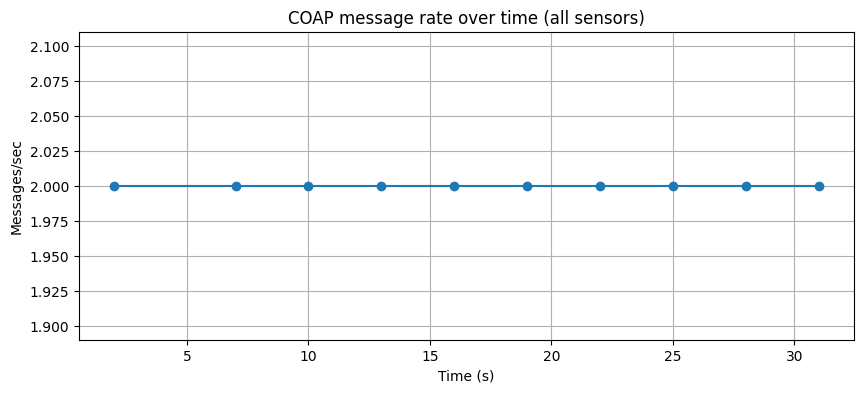

In [4]:
import matplotlib.pyplot as plt

bin_sec = 1.0
bins = (df["elapsed_s"] // bin_sec).astype(int)
counts = bins.value_counts().sort_index()

t = counts.index.values * bin_sec
rate = counts.values / bin_sec

plt.figure(figsize=(10,4))
plt.plot(t, rate, marker="o")
plt.title(f"{protocol.upper()} message rate over time (all sensors)")
plt.xlabel("Time (s)")
plt.ylabel("Messages/sec")
plt.grid(True)
plt.show()

# 4. Plot messages over time (MQTT)

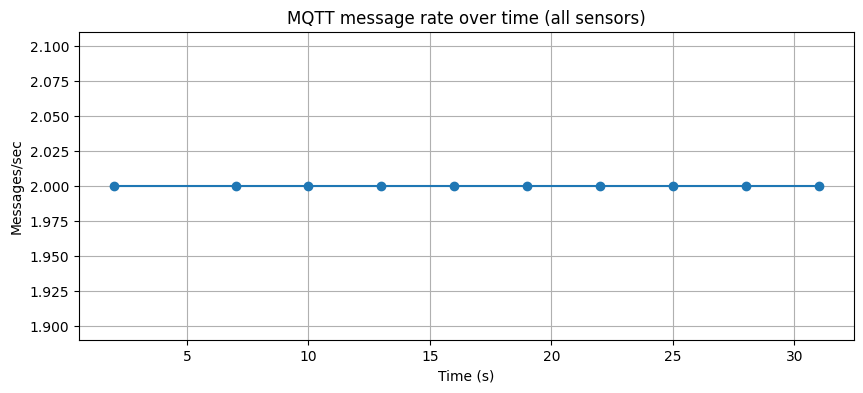

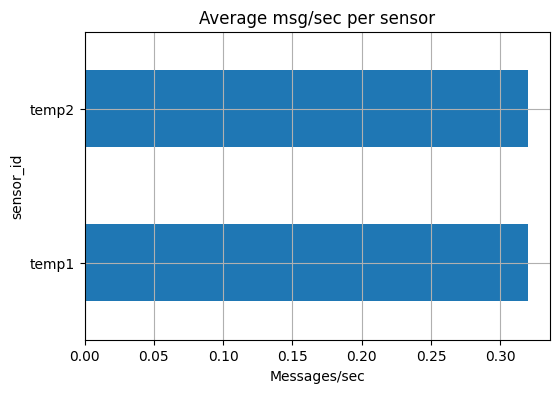

In [5]:
import matplotlib.pyplot as plt

# bucket messages into 1-second bins
bin_sec = 1.0
bins = (df["elapsed_s"] // bin_sec).astype(int)

counts = bins.value_counts().sort_index()
t = counts.index.values * bin_sec
rate = counts.values / bin_sec

plt.figure(figsize=(10,4))
plt.plot(t, rate, marker="o")
plt.title("MQTT message rate over time (all sensors)")
plt.xlabel("Time (s)")
plt.ylabel("Messages/sec")
plt.grid(True)
plt.show()

# per-sensor average rates
duration = df["elapsed_s"].max()
per_sensor = df["sensor_id"].value_counts() / max(duration, 1e-9)

plt.figure(figsize=(6,4))
per_sensor.sort_values().plot(kind="barh")
plt.title("Average msg/sec per sensor")
plt.xlabel("Messages/sec")
plt.grid(True)
plt.show()

# 4. PCAP quick check (MQTT 1883 vs CoAP 5683)

In [6]:
import subprocess

mqtt_pcap = run_dir / "mqtt.pcap"
coap_pcap = run_dir / "coap.pcap"

if mqtt_pcap.exists():
    pcap_path = mqtt_pcap
    print("Using PCAP:", pcap_path)
    !tcpdump -r {pcap_path} -n -c 5
    !tcpdump -r {pcap_path} -n | wc -l

if coap_pcap.exists():
    pcap_path = coap_pcap
    print("Using PCAP:", pcap_path)
    !tcpdump -r {pcap_path} -n -c 5
    !tcpdump -r {pcap_path} -n | wc -l

Using PCAP: /home/chief/CMPE148-IoT-Project/results/run_20260419_230637/coap.pcap
reading from file /home/chief/CMPE148-IoT-Project/results/run_20260419_230637/coap.pcap, link-type LINUX_SLL2 (Linux cooked v2), snapshot length 262144
23:06:41.469190 eth0  In  IP 10.0.0.11.60057 > 10.0.0.1.5683: UDP, length 98
23:06:41.470159 eth0  Out IP 10.0.0.1.5683 > 10.0.0.11.60057: UDP, length 9
23:06:41.471153 eth0  In  IP 10.0.0.12.37106 > 10.0.0.1.5683: UDP, length 98
23:06:41.472298 eth0  Out IP 10.0.0.1.5683 > 10.0.0.12.37106: UDP, length 9
23:06:46.552837 eth0  In  IP 10.0.0.11.60057 > 10.0.0.1.5683: UDP, length 98
reading from file /home/chief/CMPE148-IoT-Project/results/run_20260419_230637/coap.pcap, link-type LINUX_SLL2 (Linux cooked v2), snapshot length 262144
42


# 5. Compare latest MQTT run vs latest CoAP run

Latest MQTT run: /home/chief/CMPE148-IoT-Project/results/run_20260419_230557
Latest CoAP run: /home/chief/CMPE148-IoT-Project/results/run_20260419_230637
MQTT: rows=20, duration=31.06s, avg_msg/sec=0.644
MQTT: latency_ms mean=7.96, p50=6.42, p95=15.44
CoAP: rows=20, duration=31.28s, avg_msg/sec=0.639
CoAP: latency_ms mean=8.69, p50=9.06, p95=10.57


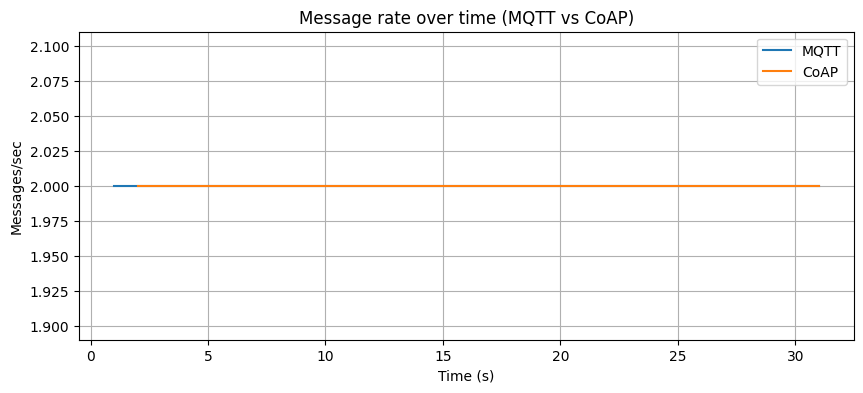

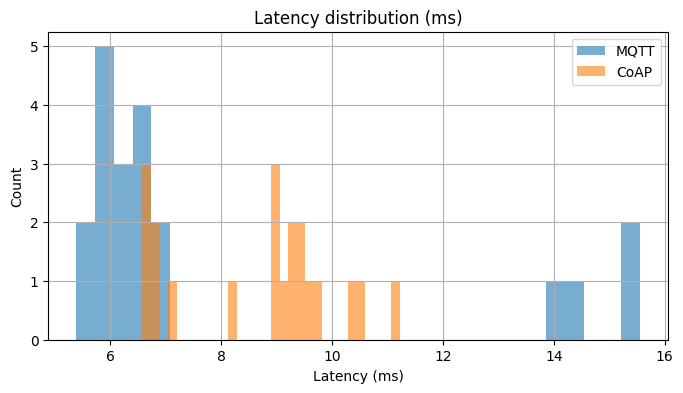

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent          # notebooks/ -> repo root
results_dir = REPO / "results"
runs = sorted([p for p in results_dir.glob("run_*") if p.is_dir()])

def load_run(run_dir: Path, proto: str):
    csv_path = run_dir / f"{proto}.csv"
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    df["elapsed_s"] = df["elapsed_s"].astype(float)
    df["latency_ms"] = pd.to_numeric(df.get("latency_ms", None), errors="coerce")
    return df

# Find most recent run folder that contains mqtt.csv / coap.csv
mqtt_run = next((r for r in reversed(runs) if (r/"mqtt.csv").exists()), None)
coap_run = next((r for r in reversed(runs) if (r/"coap.csv").exists()), None)

print("Latest MQTT run:", mqtt_run)
print("Latest CoAP run:", coap_run)

mqtt_df = load_run(mqtt_run, "mqtt") if mqtt_run else None
coap_df = load_run(coap_run, "coap") if coap_run else None

def summarize(df, name):
    if df is None:
        print(name, "missing")
        return
    dur = df["elapsed_s"].max()
    print(f"{name}: rows={len(df)}, duration={dur:.2f}s, avg_msg/sec={len(df)/max(dur,1e-9):.3f}")
    lat = df["latency_ms"].dropna()
    if len(lat) > 0:
        print(f"{name}: latency_ms mean={lat.mean():.2f}, p50={lat.quantile(0.5):.2f}, p95={lat.quantile(0.95):.2f}")

summarize(mqtt_df, "MQTT")
summarize(coap_df, "CoAP")

# Plot message rate over time for each
def rate_series(df, bin_sec=1.0):
    bins = (df["elapsed_s"] // bin_sec).astype(int)
    counts = bins.value_counts().sort_index()
    t = counts.index.values * bin_sec
    r = counts.values / bin_sec
    return t, r

plt.figure(figsize=(10,4))
if mqtt_df is not None:
    t, r = rate_series(mqtt_df)
    plt.plot(t, r, label="MQTT")
if coap_df is not None:
    t, r = rate_series(coap_df)
    plt.plot(t, r, label="CoAP")
plt.title("Message rate over time (MQTT vs CoAP)")
plt.xlabel("Time (s)")
plt.ylabel("Messages/sec")
plt.grid(True)
plt.legend()
plt.show()

# Plot latency distributions (if available)
plt.figure(figsize=(8,4))
if mqtt_df is not None and mqtt_df["latency_ms"].notna().any():
    plt.hist(mqtt_df["latency_ms"].dropna(), bins=30, alpha=0.6, label="MQTT")
if coap_df is not None and coap_df["latency_ms"].notna().any():
    plt.hist(coap_df["latency_ms"].dropna(), bins=30, alpha=0.6, label="CoAP")
plt.title("Latency distribution (ms)")
plt.xlabel("Latency (ms)")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.show()

# 6. Overhead comparison (pcap bytes/packets per delivered message)

In [8]:
import os
from pathlib import Path

def pcap_stats(run_dir: Path, proto: str):
    pcap = run_dir / f"{proto}.pcap"
    csv  = run_dir / f"{proto}.csv"
    if not (pcap.exists() and csv.exists()):
        return None

    pcap_bytes = pcap.stat().st_size
    msgs = sum(1 for _ in open(csv, "r")) - 1  # minus header
    return {"pcap_bytes": pcap_bytes, "msgs": msgs}

mqtt_stats = pcap_stats(mqtt_run, "mqtt") if mqtt_run else None
coap_stats = pcap_stats(coap_run, "coap") if coap_run else None

print("MQTT:", mqtt_stats)
print("CoAP:", coap_stats)

if mqtt_stats and mqtt_stats["msgs"] > 0:
    print("MQTT bytes/msg:", mqtt_stats["pcap_bytes"] / mqtt_stats["msgs"])
if coap_stats and coap_stats["msgs"] > 0:
    print("CoAP bytes/msg:", coap_stats["pcap_bytes"] / coap_stats["msgs"])

MQTT: {'pcap_bytes': 13969, 'msgs': 20}
CoAP: {'pcap_bytes': 5049, 'msgs': 20}
MQTT bytes/msg: 698.45
CoAP bytes/msg: 252.45
